# Validation Strategies

### Loading Libraries

In [2]:
%cd ../..

/Users/joaquinromero/Desktop


In [15]:
# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import plotly.express as px
import plotly.graph_objects as go

# Scikit-Learn
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection._split import _BaseKFold
from sklearn.utils.validation import _num_samples, indexable

#### `Utility Functions`

In [4]:
def plot_temporal_cv_splits(cv, a):
    trn_idxs= []
    val_idxs = []
    for trn_idx, val_idx in cv.split(a):
        trn_idxs.append((np.min(trn_idx),np.max(trn_idx)))
        val_idxs.append((np.min(val_idx),np.max(val_idx)))
    w=0.8
    y= np.arange(len(trn_idxs))+1
    fig = go.Figure()
    for x, ((trn_start, trn_end),(val_start, val_end)) in enumerate(zip(trn_idxs,val_idxs)):
        fig.add_shape(type="rect", y0=x, y1=x+w, x0=trn_start, x1=trn_end, fillcolor="#0356fc", line=dict(
            color="#002570",
            width=0.5,
        ))
        fig.add_shape(type="rect", y0=x, y1=x+w, x0=val_start-1, x1=val_end-1, fillcolor="#cf0053", line=dict(
            color="#69002a",
            width=0.5,
        ))
        if trn_end!= val_start-1:
            #plotting gap
            fig.add_shape(type="rect", y0=x, y1=x+w, x0=trn_end, x1=val_start, fillcolor="#0f172e", line=dict(
                color="#0f172e",
                width=0.5,
            ))

    fig.update_xaxes(range = [0,len(a)])
    fig.update_yaxes(range = [cv.get_n_splits(), 0])
    return fig

In [5]:
from itertools import groupby
from operator import itemgetter

def plot_cv_splits(cv, a):
    w=0.8
    y= np.arange(cv.get_n_splits())+1
    _range = np.arange(len(a))
    fig = go.Figure()
    for x, (trn_idx, val_idx) in enumerate(cv.split(a)):
        val_mask = np.isin(_range, val_idx)
        trn_mask = np.isin(_range, trn_idx)
        gap_mask = np.logical_not(np.logical_xor(trn_mask, val_mask))
        fig.add_shape(type="rect", y0=x, y1=x+w, x0=0, x1=N, fillcolor="#0356fc", line=dict(
            color="#002570",
            width=0.5,
        ))
        fig.add_shape(type="rect", y0=x, y1=x+w, x0=np.min(val_idx)-1, x1=np.max(val_idx), fillcolor="#cf0053", line=dict(
            color="#69002a",
            width=0.5,
        ))
        if gap_mask.sum()>0:
            #plotting gap
            gap = _range[gap_mask]
            #splitting based on continuous gap
            for k, g in groupby(enumerate(gap), lambda i_x: i_x[0] - i_x[1]):
                _gap = list(map(itemgetter(1), g))
                gap_min, gap_max = np.min(_gap), np.max(_gap)
                fig.add_shape(type="rect", y0=x, y1=x+w, x0=gap_min-1, x1=gap_max, fillcolor="#0f172e", line=dict(
                    color="#0f172e",
                    width=0.5,
                ))

    fig.update_xaxes(range = [0,len(a)])
    fig.update_yaxes(range = [0,cv.get_n_splits()])
    return fig

## Validation Strategies

In [6]:
N = 50

a = np.arange(N)

#### Repeated Holdout with no Overlap (`Expanding Window`)

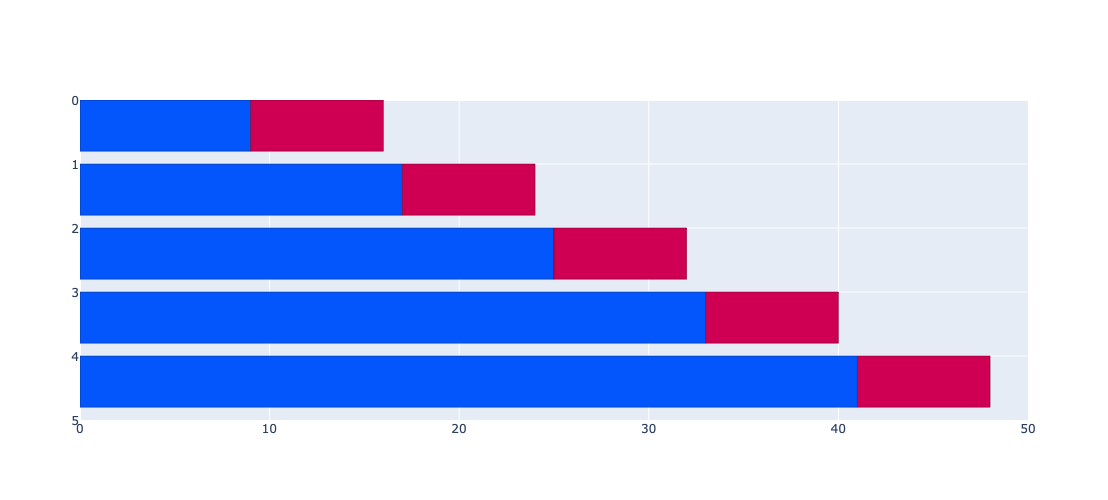

In [9]:
cv = TimeSeriesSplit(n_splits=5)
fig = plot_temporal_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()

#### Repeated Holdout with no Overlap (`Rolling Window`)

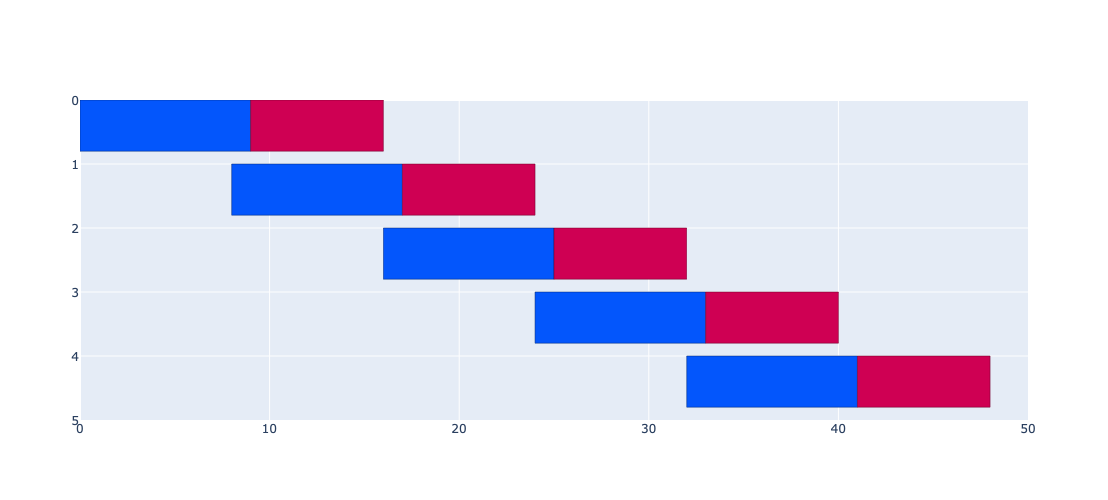

In [10]:
cv = TimeSeriesSplit(n_splits=5, max_train_size=10)
fig = plot_temporal_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()

#### Repeated Holdout with no Overlap with Gaps (`Expanding Window`)

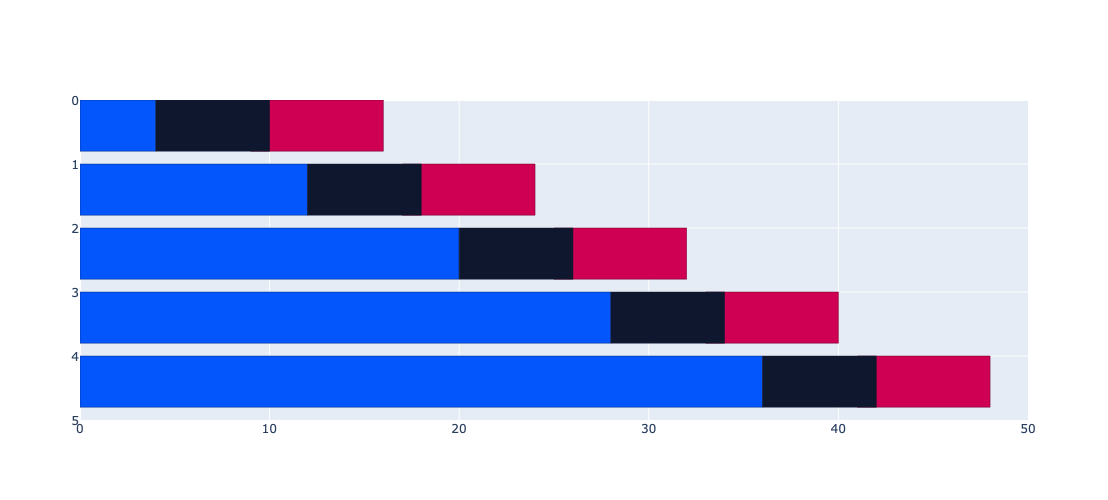

In [11]:
cv = TimeSeriesSplit(n_splits=5, gap=5)
fig = plot_temporal_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()

#### Repeated Holdout with no Overlap with Gaps (`Rolling Window`)

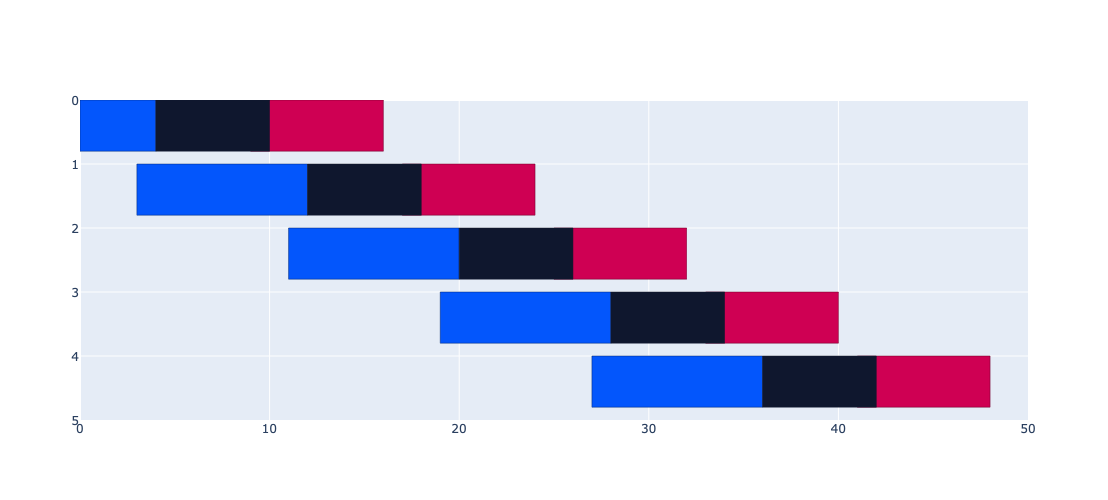

In [12]:
cv = TimeSeriesSplit(n_splits=5, max_train_size=10, gap=5)
fig = plot_temporal_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()

## Blocked Cross-Validation

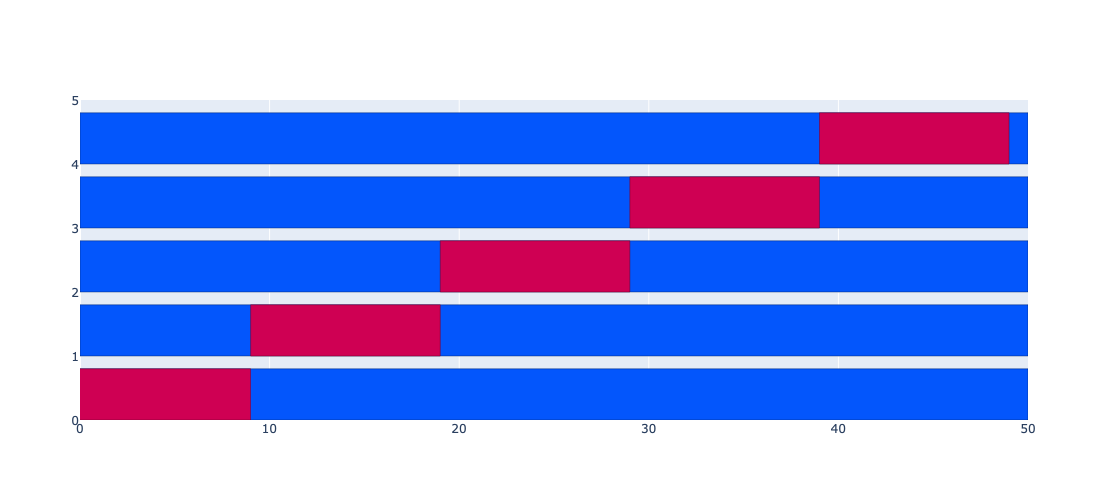

In [14]:
cv = KFold(n_splits=5, shuffle=False) #blocked CV

fig = plot_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()

### Blocked Cross-Validation with Gaps

#### `Implementation`

In [16]:
class KFoldGap(_BaseKFold):
    def __init__(self, n_splits=5, gap=0, *, random_state=None):
        self.gap = gap
        super().__init__(n_splits=n_splits, shuffle=False, random_state=random_state)

    def _iter_test_indices(self, X, y=None, groups=None):
        n_samples = _num_samples(X)
        indices = np.arange(n_samples)
        n_splits = self.n_splits
        fold_sizes = np.full(n_splits, n_samples // n_splits, dtype=int)
        fold_sizes[: n_samples % n_splits] += 1
        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            yield start,stop
            current = stop
    
    def split(self, X, y=None, groups=None):
        X, y, groups = indexable(X, y, groups)
        indices = np.arange(_num_samples(X))
        for test_start, test_stop in self._iter_test_indices(X, y, groups):
            test_index = indices[test_start:test_stop]
            inv_train_index = indices[max(test_start-self.gap,0):test_stop+self.gap]
            test_mask = np.zeros(_num_samples(X), dtype=bool)
            test_mask[inv_train_index] = True
            train_index = indices[np.logical_not(test_mask)]
            yield train_index, test_index

#### `Usage`

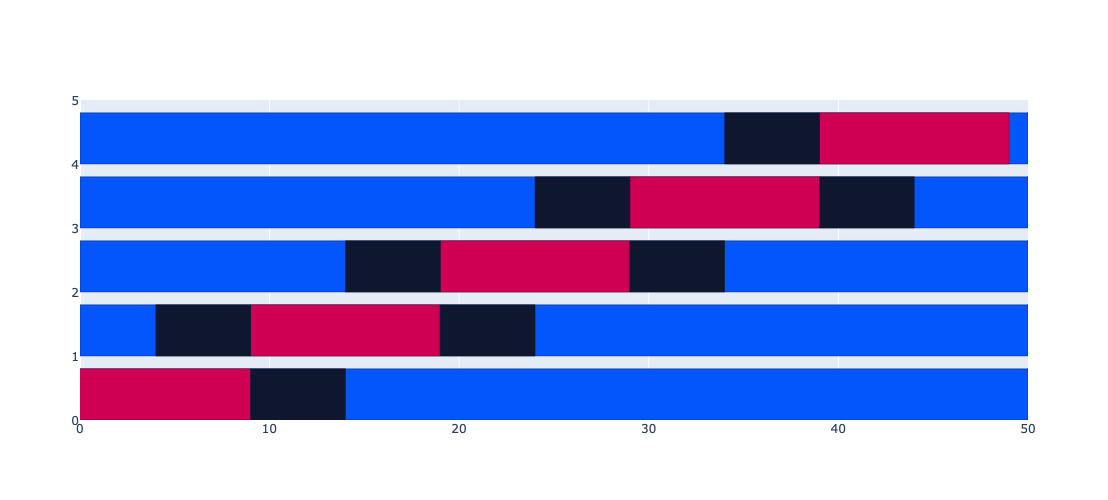

In [17]:
cv = KFoldGap(n_splits=5, gap=5) #blocked CV
fig = plot_cv_splits(cv, a)
fig.update_layout(width=900, height=500)
fig.show()